# Homework 08 - Exploratory Data Analysis

**Course:** FRE 5040 Applied Financial Engineering
**Dataset:** one year of daily closes for the three funds in the Portfolio Drift Monitor
(VTI 60%, VXUS 30%, BND 10%), pulled from yfinance and saved to
`data/raw/portfolio_prices.csv`.

The starter notebook offered a synthetic generator. I used the project's own data
instead, because the questions this stage is supposed to answer (what shape is the
data, what does it do over time, what should Stage 09 build) only have real answers
if the data is real.

**What this notebook does**

| Section | Requirement it covers |
|---|---|
| 2 | structure, dtypes, missing counts |
| 4 | numeric profile: describe, skew, kurtosis |
| 5 | categorical profile: value counts for every non-numeric column |
| 6 | six distributional views (three required) |
| 7 | three bivariate relationships (two required) |
| 8 | at least one variable over time, with the trend read |
| 9 | correlation heatmap (optional stretch) |
| 10 | `src/eda.py` imported and called |
| 11 | daily vs monthly granularity (stretch) |
| 12 | insights, assumptions, next steps |

Run order: Kernel -> Restart Kernel and Run All Cells.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy pandas scipy seaborn matplotlib

## 0. Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew

# So `from src.eda import ...` works no matter where the kernel started.
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

RAW = Path('data/raw')
PROC = Path('data/processed')
PROC.mkdir(parents=True, exist_ok=True)

print('working from:', ROOT.name)
print('pandas', pd.__version__, '| seaborn', sns.__version__)

working from: homework08
pandas 2.3.3 | seaborn 0.13.2


## 1. The dataset

One row per (date, fund): the daily close. 753 rows is 251 trading days times 3 funds.
The file was produced by the project's Stage 04 ingestion cell and cleaned by
`clean_prices` in Stage 06, so every date here has a close for all three funds.

In [3]:
prices = pd.read_csv(RAW / 'portfolio_prices.csv', parse_dates=['date'])

print('shape:', prices.shape)
print('window:', prices['date'].min().date(), '->', prices['date'].max().date())
print('funds :', sorted(prices['ticker'].unique()))
prices.head()

shape: (753, 3)
window: 2025-08-29 -> 2026-08-28
funds : ['BND', 'VTI', 'VXUS']


,date,ticker,close
0,2025-08-29,BND,73.800003
1,2025-08-29,VTI,318.200012
2,2025-08-29,VXUS,71.370003
3,2025-09-02,BND,73.400002
4,2025-09-02,VTI,315.989990


## 2. First look: structure and missingness

In [4]:
prices.info()
print()
print('missing values per column')
print(prices.isna().sum().to_string())
print()
display(prices.head(3))
display(prices.tail(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    753 non-null    datetime64[ns]
 1   ticker  753 non-null    object        
 2   close   753 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 17.8+ KB

missing values per column
date      0
ticker    0
close     0



,date,ticker,close
0,2025-08-29,BND,73.800003
1,2025-08-29,VTI,318.200012
2,2025-08-29,VXUS,71.370003


,date,ticker,close
750,2026-08-28,BND,72.309998
751,2026-08-28,VTI,379.359985
752,2026-08-28,VXUS,87.519997


**What?** Three columns, correct dtypes after `parse_dates`, zero missing values.

**So what?** Zero missingness in a market data pull is not luck, it is the Stage 06
cleaner doing its job: `drop_incomplete_days` removes any date that is missing a close
for even one fund, because a portfolio weight computed from two funds out of three is
not a smaller number, it is a wrong one. The cost of that rule is invisible here and
worth naming: some dates were deleted rather than repaired.

**Now what?** The interesting missingness in this project is not in the file, it is in
the calendar. Section 8 goes looking for it.

## 3. Build the analysis frame

The raw file has three columns. Almost every question in this stage is about a quantity
derived from them: the daily return, the portfolio weight, and the drift in percentage
points. Those get built once, here, and everything below profiles the result.

Weights follow the project's convention: buy the 60/30/10 target on day one and never
rebalance, so drift is what the market does to a portfolio left alone.

In [5]:
TARGET_WEIGHTS = {'VTI': 0.60, 'VXUS': 0.30, 'BND': 0.10}
TICKERS = list(TARGET_WEIGHTS)
AMBER_PP, RED_PP = 3.0, 5.0          # the principal's policy, same numbers as src/utils.py
PORTFOLIO_VALUE = 1_000_000

wide = prices.pivot(index='date', columns='ticker', values='close')[TICKERS]

targets = np.array([TARGET_WEIGHTS[t] for t in TICKERS])
shares = (PORTFOLIO_VALUE * targets) / wide.iloc[0].to_numpy()
values = wide.to_numpy() * shares
weights = values / values.sum(axis=1, keepdims=True)

weights_df = pd.DataFrame(weights, index=wide.index, columns=TICKERS)
drift_df = (weights_df - targets) * 100                     # percentage points
rets = wide.pct_change(fill_method=None)                    # first row is NaN by definition

assert np.allclose(weights_df.iloc[0], targets), 'day 0 must sit exactly on target'
print(f'{len(wide)} trading days, {len(TICKERS)} funds')

251 trading days, 3 funds


In [6]:
def to_long(frame, value_name):
    return (frame.reset_index()
                 .melt(id_vars='date', var_name='ticker', value_name=value_name))


panel = (to_long(wide, 'close')
         .merge(to_long(rets, 'ret'), on=['date', 'ticker'])
         .merge(to_long(weights_df, 'weight'), on=['date', 'ticker'])
         .merge(to_long(drift_df, 'drift_pp'), on=['date', 'ticker'])
         .sort_values(['date', 'ticker'])
         .reset_index(drop=True))

# Four categorical columns, so the categorical profile in section 5 has something to say.
mag = panel['drift_pp'].abs()
panel['flag'] = np.where(mag > RED_PP, 'red',
                np.where(mag >= AMBER_PP, 'amber', 'green'))
panel['direction'] = np.where(panel['ret'] > 0, 'up',
                     np.where(panel['ret'] < 0, 'down', 'flat'))
panel.loc[panel['ret'].isna(), 'direction'] = np.nan
panel['asset_class'] = np.where(panel['ticker'] == 'BND', 'bond', 'equity')
panel['quarter'] = panel['date'].dt.to_period('Q').astype(str)

print('panel shape:', panel.shape)
panel.head()

panel shape: (753, 10)


,date,ticker,close,ret,weight,drift_pp,flag,direction,asset_class,quarter
0,2025-08-29,BND,73.800003,NaN,0.100000,0.000000,green,NaN,bond,2025Q3
1,2025-08-29,VTI,318.200012,NaN,0.600000,0.000000,green,NaN,equity,2025Q3
2,2025-08-29,VXUS,71.370003,NaN,0.300000,0.000000,green,NaN,equity,2025Q3
3,2025-09-02,BND,73.400002,-0.005420,0.100140,0.014004,green,down,bond,2025Q3
4,2025-09-02,VTI,315.989990,-0.006945,0.599919,-0.008121,green,down,equity,2025Q3


## 4. Numeric profile

In [7]:
NUMERIC = ['close', 'ret', 'weight', 'drift_pp']

profile = panel.groupby('ticker')[['ret']].describe().round(5)
display(profile)

# Per-fund, because a single pooled profile of `ret` mixes a bond fund with two equity
# funds and reports a standard deviation that describes neither.
rows = []
for t in TICKERS:
    s = rets[t].dropna()
    rows.append({
        'fund': t,
        'n': len(s),
        'mean_%': s.mean() * 100,
        'std_%': s.std() * 100,
        'ann_vol_%': s.std() * np.sqrt(252) * 100,
        'min_%': s.min() * 100,
        'max_%': s.max() * 100,
        'skew': skew(s),
        'excess_kurtosis': kurtosis(s),
    })
return_profile = pd.DataFrame(rows).set_index('fund').round(3)
return_profile

ret                                                               
        count     mean      std      min      25%      50%      75%      max
ticker                                                                      
BND     250.0 -0.00008  0.00246 -0.00800 -0.00165  0.00000  0.00172  0.00576
VTI     250.0  0.00074  0.00823 -0.02679 -0.00367  0.00126  0.00564  0.02929
VXUS    250.0  0.00087  0.01071 -0.03733 -0.00461  0.00164  0.00659  0.04114

,n,mean_%,std_%,ann_vol_%,min_%,max_%,skew,excess_kurtosis
fund,,,,,,,,
VTI,250,0.074,0.823,13.067,-2.679,2.929,-0.223,1.118
VXUS,250,0.087,1.071,17.003,-3.733,4.114,-0.124,2.005
BND,250,-0.008,0.246,3.907,-0.800,0.576,-0.276,0.066


In [8]:
drift_profile = pd.DataFrame({
    'median_pp': drift_df.median(),
    'p90_pp': drift_df.abs().quantile(0.90),
    'p99_pp': drift_df.abs().quantile(0.99),
    'worst_pp': drift_df.abs().max(),
    'skew': [skew(drift_df[t]) for t in TICKERS],
}).round(3)
drift_profile['worst_over_target_%'] = (drift_profile['worst_pp']
                                        / (pd.Series(TARGET_WEIGHTS) * 100) * 100).round(1)
drift_profile

,median_pp,p90_pp,p99_pp,worst_pp,skew,worst_over_target_%
VTI,0.095,0.956,1.435,1.553,-0.853,2.6
VXUS,0.923,1.534,2.158,2.233,0.103,7.4
BND,-0.634,1.480,1.750,1.769,-0.367,17.7


**What?** Annualized volatility runs 13.1% (VTI), 17.0% (VXUS) and 3.9% (BND). All three
return series are slightly negatively skewed. Excess kurtosis is 1.1 for VTI, 2.0 for
VXUS and 0.07 for BND.

**So what?** Two things.

Excess kurtosis is measured against a normal distribution, where the value is 0. VXUS at
2.0 has visibly heavier tails than normal, which means a z-score rule on VXUS returns is
mis-calibrated exactly where it is being asked to work: a 3-sigma cutoff assumes a tail
that this series does not have. That retroactively justifies Stage 07's choice of the
IQR rule as the primary detector. BND at 0.07 is close to normal, which is the one place
a z-score would behave.

The last column is the Stage 07 unit problem in one number. BND's worst drift is 1.77pp,
which is 17.7% of its 10% target. VTI's worst is 1.55pp, which is 2.6% of its 60% target.
The same threshold in percentage points is a far looser rule for the small position than
for the large one.

**Now what?** Any Stage 09 feature built on returns should be built per fund, not pooled.

## 5. Categorical profile

`.describe()` covers numeric columns only, so a categorical column can be entirely
degenerate and never appear in a numeric profile. Every non-numeric column gets counted
here, with proportions, because a raw count hides how lopsided a split is.

In [9]:
from src.eda import categorical_profile

cat = categorical_profile(panel)
for col, table in cat.items():
    print(f'--- {col} ---')
    print(table.to_string())
    print()

--- ticker ---
        count    pct
ticker              
BND       251  33.33
VTI       251  33.33
VXUS      251  33.33

--- flag ---
       count    pct
flag               
green    753  100.0

--- direction ---
           count    pct
direction              
up           400  53.12
down         343  45.55
flat           7   0.93
NaN            3   0.40

--- asset_class ---
             count    pct
asset_class              
equity         502  66.67
bond           251  33.33

--- quarter ---
         count    pct
quarter              
2025Q4     192  25.50
2026Q2     186  24.70
2026Q1     183  24.30
2026Q3     126  16.73
2025Q3      66   8.76



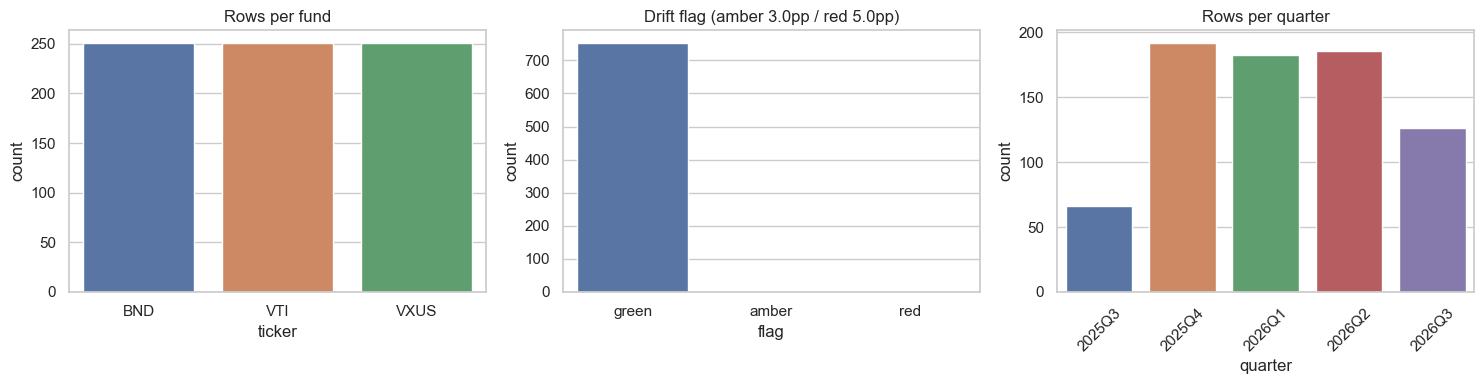

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=panel, x='ticker', ax=axes[0], hue='ticker', legend=False)
axes[0].set_title('Rows per fund')

sns.countplot(data=panel, x='flag', order=['green', 'amber', 'red'],
              ax=axes[1], hue='flag', hue_order=['green', 'amber', 'red'], legend=False)
axes[1].set_title(f'Drift flag (amber {AMBER_PP}pp / red {RED_PP}pp)')

sns.countplot(data=panel, x='quarter', ax=axes[2], hue='quarter', legend=False)
axes[2].set_title('Rows per quarter')
axes[2].tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

**What?** `ticker` is exactly 251 / 251 / 251. `flag` is 100% green, with amber and red
never appearing. `direction` is a near-even up/down split. `quarter` is uneven only
because the window starts in late August and ends in late August.

**So what?** The balanced `ticker` split is not a coincidence to note and move past, it
is a passing test: Stage 06's `drop_incomplete_days` guarantees it, so any imbalance
would mean the cleaner had failed or been skipped.

`flag` at 100% green is the finding. As a feature it is a constant wearing a disguise,
and `flag_columns` in section 10 picks it up automatically. As a monitor it is the
result Stage 07 documented: over 753 fund-days, the alarm this whole project exists to
raise has never once gone off. Section 8 works out why, and whether that is likely to
last.

**Now what?** `flag` cannot be a model feature. It stays as a reporting column only.

## 6. Distributions

Six views across two figures. Returns first, because that is the input the drift is
built from, then drift itself, because that is the output the report is about.

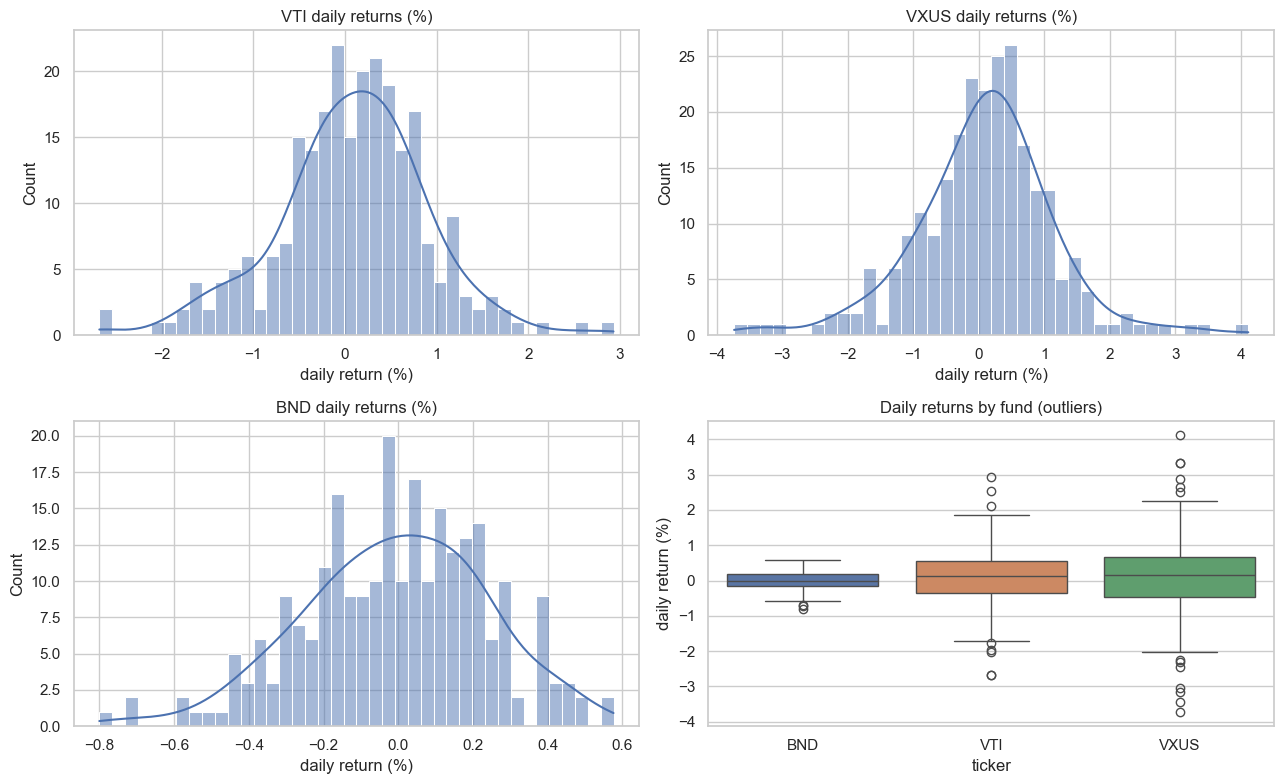

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, t in zip(axes.flat, TICKERS):
    sns.histplot(rets[t].dropna() * 100, kde=True, ax=ax, bins=40)
    ax.set_title(f'{t} daily returns (%)')
    ax.set_xlabel('daily return (%)')

sns.boxplot(data=panel, x='ticker', y=panel['ret'] * 100,
            ax=axes[1, 1], hue='ticker', legend=False)
axes[1, 1].set_title('Daily returns by fund (outliers)')
axes[1, 1].set_ylabel('daily return (%)')

fig.tight_layout()
plt.show()

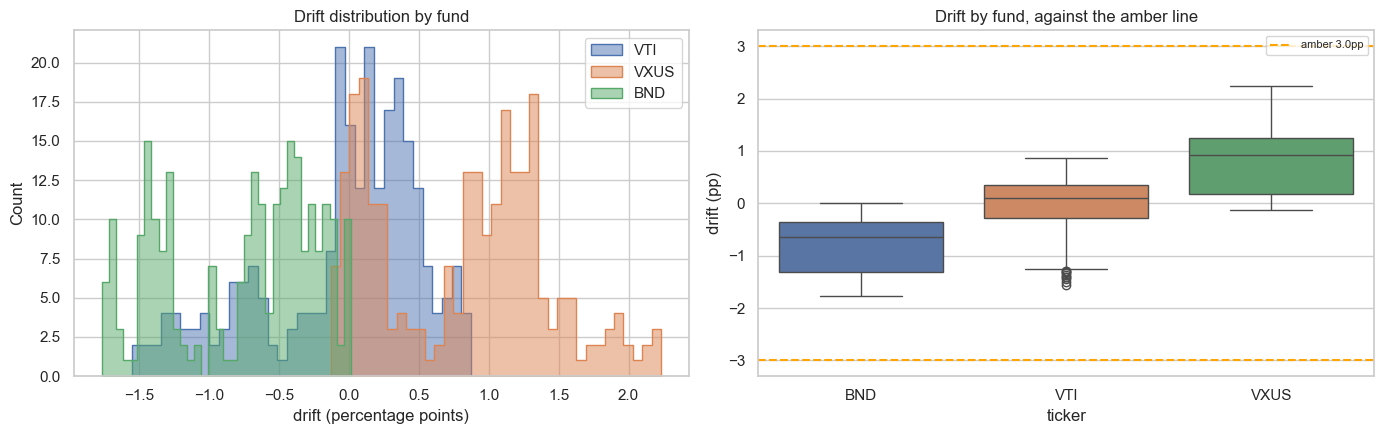

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for t in TICKERS:
    sns.histplot(drift_df[t], ax=axes[0], bins=35, label=t, alpha=0.5, element='step')
axes[0].set_title('Drift distribution by fund')
axes[0].set_xlabel('drift (percentage points)')
axes[0].legend()

sns.boxplot(data=panel, x='ticker', y='drift_pp', ax=axes[1], hue='ticker', legend=False)
axes[1].axhline(AMBER_PP, color='orange', linestyle='--', label=f'amber {AMBER_PP}pp')
axes[1].axhline(-AMBER_PP, color='orange', linestyle='--')
axes[1].set_title('Drift by fund, against the amber line')
axes[1].set_ylabel('drift (pp)')
axes[1].legend(loc='upper right', fontsize=8)

fig.tight_layout()
plt.show()

**What?** The return histograms are centred near zero and roughly symmetric, with BND's
an order of magnitude narrower than the two equity funds. The drift distributions are
not centred on zero: VXUS sits mostly positive, BND mostly negative, VTI straddles it.
The amber line in the right panel is so far above the boxes that the plot has to be
stretched to show both.

**So what?** A distribution of drift that is not centred on zero is the single most
important thing on this page. Drift that oscillated around zero would be noise, and the
right response would be to leave it alone. Drift with a non-zero centre is a position
that has been moving in one direction, and that is a different problem with a different
fix. Section 8 confirms which of the two this is.

**Now what?** Do not log-transform returns. They are already near-symmetric and contain
negatives. The skew worth acting on in Stage 09 is in `close`, not in `ret`.

## 7. Relationships

Three pairs. The first two are return against return, which is the question of whether
the three funds are actually three things. The third is drift against drift, which turns
out to be a trap.

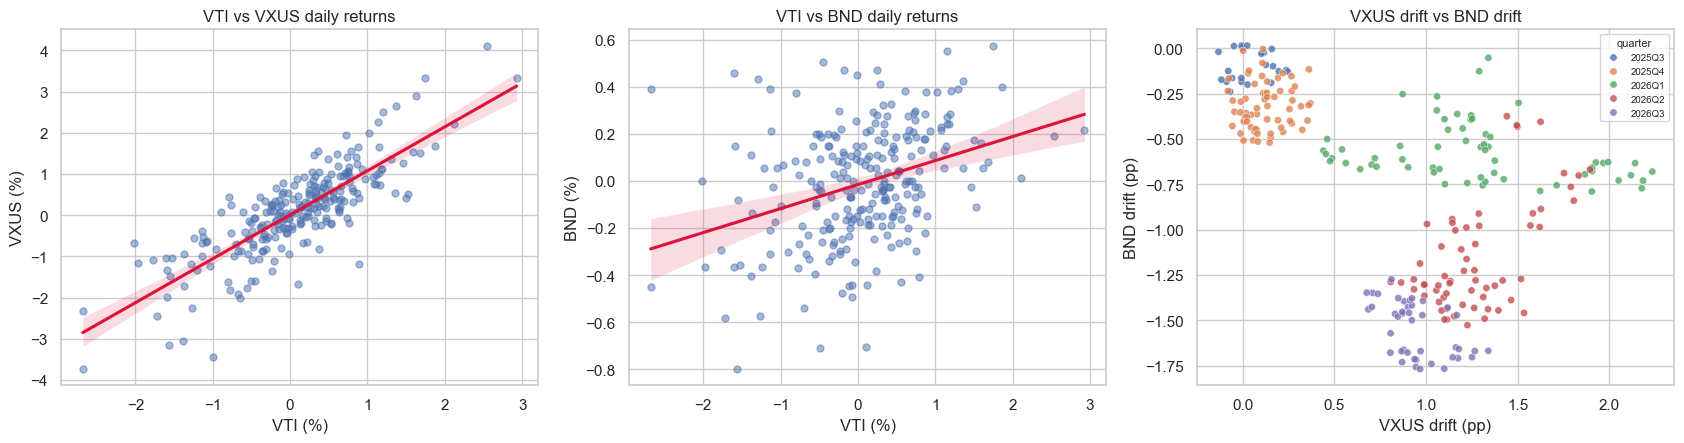

return correlations
ticker    VTI   VXUS    BND
ticker                     
VTI     1.000  0.820  0.341
VXUS    0.820  1.000  0.461
BND     0.341  0.461  1.000


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

sns.regplot(x=rets['VTI'] * 100, y=rets['VXUS'] * 100, ax=axes[0],
            scatter_kws={'alpha': 0.5, 's': 25}, line_kws={'color': 'crimson'})
axes[0].set_title('VTI vs VXUS daily returns')
axes[0].set_xlabel('VTI (%)'); axes[0].set_ylabel('VXUS (%)')

sns.regplot(x=rets['VTI'] * 100, y=rets['BND'] * 100, ax=axes[1],
            scatter_kws={'alpha': 0.5, 's': 25}, line_kws={'color': 'crimson'})
axes[1].set_title('VTI vs BND daily returns')
axes[1].set_xlabel('VTI (%)'); axes[1].set_ylabel('BND (%)')

sns.scatterplot(x=drift_df['VXUS'], y=drift_df['BND'],
                hue=drift_df.index.to_period('Q').astype(str),
                ax=axes[2], s=28, alpha=0.8)
axes[2].set_title('VXUS drift vs BND drift')
axes[2].set_xlabel('VXUS drift (pp)'); axes[2].set_ylabel('BND drift (pp)')
axes[2].legend(title='quarter', fontsize=7, title_fontsize=8)

fig.tight_layout()
plt.show()

print('return correlations')
print(rets.corr().round(3).to_string())

**What?** VTI and VXUS returns correlate at 0.82, so one explains about 67% of the
other's daily variance. VTI and BND correlate at 0.34. The third panel shows VXUS and
BND drift moving in a tight negative band, with the quarters laid out along it like beads
on a string rather than scattered through it.

**So what?** The 0.82 is a warning for Stage 09. Two features that share two thirds of
their variance are close to one feature, and feeding both to a linear model produces
unstable coefficients that flip sign on a slightly different sample. BND at 0.34 is
genuinely carrying different information, which is the entire argument for holding it.

The third panel is a trap worth stating explicitly. Portfolio weights sum to one by
construction, so the three drift columns sum to zero. Their correlations are therefore
forced negative by arithmetic, not discovered in the market. Section 9 comes back to
this. What is real in that panel is the ordering of the quarters, which is a time effect,
not a relationship between the two funds.

**Now what?** Pick one of VTI / VXUS, or replace both with a spread, before modelling.
Never read the drift correlation matrix as a diversification result.

## 8. Over time

This is the section Stage 09 and Stage 10b actually depend on. Two questions: is the
date axis sound, and what is the series doing along it.

In [14]:
from src.eda import time_axis_report

daily = wide.reset_index()[['date']]          # one row per trading day

print('--- the long panel (one row per fund per day) ---')
for k, v in time_axis_report(panel, 'date').items():
    if k != 'missing_periods':
        print(f'  {k:<20} {v}')

print()
print('--- the daily axis, against a CALENDAR-day grid ---')
cal = time_axis_report(daily, 'date', freq='D')
for k, v in cal.items():
    if k != 'missing_periods':
        print(f'  {k:<20} {v}')

print()
print('--- the daily axis, against a BUSINESS-day grid ---')
bus = time_axis_report(daily, 'date', freq='B')
for k, v in bus.items():
    if k != 'missing_periods':
        print(f'  {k:<20} {v}')
print('  business days genuinely absent:')
for d in bus['missing_periods']:
    print('   ', d.date())

--- the long panel (one row per fund per day) ---
  n_rows               753
  start                2025-08-29 00:00:00
  end                  2026-08-28 00:00:00
  is_sorted            True
  n_duplicate_dates    502
  n_missing_periods    114

--- the daily axis, against a CALENDAR-day grid ---
  n_rows               251
  start                2025-08-29 00:00:00
  end                  2026-08-28 00:00:00
  is_sorted            True
  n_duplicate_dates    0
  n_missing_periods    114

--- the daily axis, against a BUSINESS-day grid ---
  n_rows               251
  start                2025-08-29 00:00:00
  end                  2026-08-28 00:00:00
  is_sorted            True
  n_duplicate_dates    0
  n_missing_periods    10
  business days genuinely absent:
    2025-09-01
    2025-11-27
    2025-12-25
    2026-01-01
    2026-01-19
    2026-02-16
    2026-04-03
    2026-05-25
    2026-06-19
    2026-07-03


In [15]:
gaps = daily['date'].diff().dt.days.dropna().astype(int)
print('calendar days between consecutive rows')
print(gaps.value_counts().sort_index().to_string())

calendar days between consecutive rows
date
1    195
2      3
3     45
4      7


**What?** The panel reports 502 duplicate dates, which is correct and expected: three
funds share every date. On the daily axis there are no duplicates, the rows are sorted,
and 114 calendar days are missing. Against a business-day grid only 10 are missing, and
all ten are named US market holidays. The gaps between consecutive rows are 1 day
(195 times), 3 days (45 times, weekends), 4 days (7 times, holiday weekends) and 2 days
(3 times).

**So what?** This is the difference between a rolling window that means what you think
and one that does not. There is no data-quality problem here, but there is a units
problem: the axis is business-daily, not calendar-daily. A 7-row rolling mean in Stage 09
spans 9 calendar days on average and 11 across a holiday weekend. `shift(1)` means the
previous trading day, which is three calendar days earlier every Monday. If Stage 09
reindexes onto `freq='D'` to make the axis regular, it will manufacture 114 empty rows
and every rolling statistic will be diluted by them.

**Now what?** Stage 09 builds lags and rolling windows on the existing business-day
index and labels them in trading days, not calendar days. It does not reindex to `'D'`.

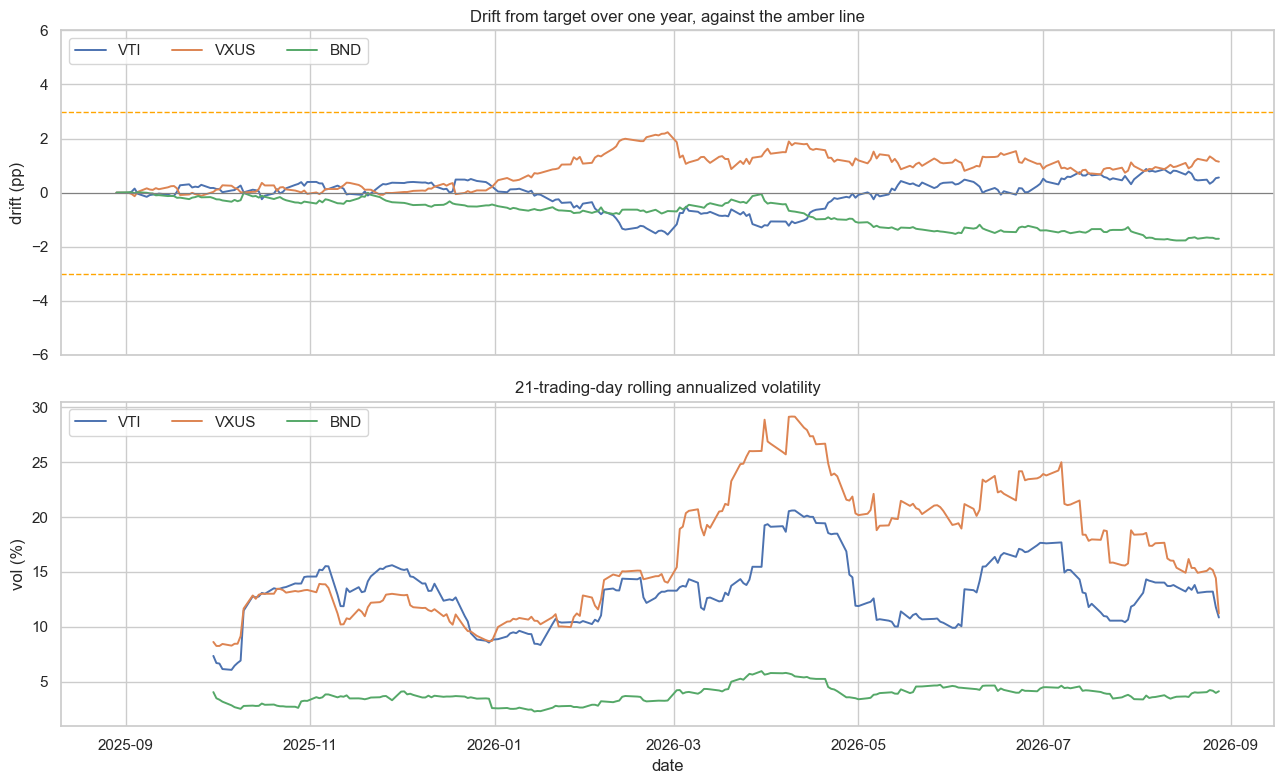

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for t in TICKERS:
    axes[0].plot(drift_df.index, drift_df[t], label=t, linewidth=1.4)
axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].axhline(AMBER_PP, color='orange', linestyle='--', linewidth=1)
axes[0].axhline(-AMBER_PP, color='orange', linestyle='--', linewidth=1)
axes[0].set_ylim(-6, 6)
axes[0].set_title('Drift from target over one year, against the amber line')
axes[0].set_ylabel('drift (pp)')
axes[0].legend(loc='upper left', ncol=3)

roll_vol = rets.rolling(21).std() * np.sqrt(252) * 100
for t in TICKERS:
    axes[1].plot(roll_vol.index, roll_vol[t], label=t, linewidth=1.4)
axes[1].set_title('21-trading-day rolling annualized volatility')
axes[1].set_ylabel('vol (%)')
axes[1].set_xlabel('date')
axes[1].legend(loc='upper left', ncol=3)

fig.tight_layout()
plt.show()

In [17]:
# Is the drift a trend or is it noise? Fit a straight line in trading-day time.
TRADING_DAYS_PER_YEAR = 251
x = np.arange(len(drift_df))

rows = []
for t in TICKERS:
    slope, _ = np.polyfit(x, drift_df[t], 1)
    per_year = slope * TRADING_DAYS_PER_YEAR
    r = np.corrcoef(x, drift_df[t])[0, 1]
    rows.append({
        'fund': t,
        'drift_rate_pp_per_year': per_year,
        'corr_with_time': r,
        'r_squared': r ** 2,
        'years_to_amber': abs(AMBER_PP / per_year) if per_year else np.inf,
        'years_to_red': abs(RED_PP / per_year) if per_year else np.inf,
    })

trend = pd.DataFrame(rows).set_index('fund').round(3)
trend

,drift_rate_pp_per_year,corr_with_time,r_squared,years_to_amber,years_to_red
fund,,,,,
VTI,0.343,0.175,0.031,8.734,14.556
VXUS,1.345,0.643,0.413,2.231,3.718
BND,-1.688,-0.929,0.863,1.777,2.961


**What?** BND's drift correlates with time at -0.93, so 86% of its variation is a
straight line. It is falling at 1.69pp per year. VXUS is rising at 1.35pp per year with
an r-squared of 0.41. VTI is close to flat at 0.34pp per year and an r-squared of 0.03.
Underneath, the funds returned +19.2% (VTI), +22.6% (VXUS) and -2.0% (BND) over the
window. Rolling volatility ranges from 6% to 21% for VTI and 8% to 29% for VXUS, in
visible clusters rather than at a constant level.

**So what?** There is no seasonality here and no level shift. There is a trend, and it is
close to deterministic in BND's case. That changes what the drift monitor is measuring.
Drift is not a portfolio wobbling around its target and occasionally poking through a
line; it is a one-way ratchet driven by a persistent return spread between equities and
bonds, and the year in this file is simply too short for the ratchet to reach 3pp.

Extrapolating the fitted rates, and being clear that this assumes the spread persists:
BND reaches amber in about 1.8 years and red in about 3.0. VXUS reaches amber in about
2.2 years and red in about 3.7. That is a much more useful statement than "the alarm has
never fired". The alarm is not broken and the threshold is not obviously wrong. The
monitor has been shown one year of a phenomenon that operates on a three-year timescale.

**Now what, for Stage 09.** Features go on the *rate* of drift, not the level. The level
is dominated by a trend, so a lagged level is almost as good a predictor of tomorrow as
today's level is, and adds nothing. The first difference, a rolling slope over 21 or 63
trading days, and the equity-minus-bond return spread are the three candidates. Rolling
volatility clusters, so a 21-day realized vol feature is worth adding as well.

**Now what, for Stage 10b.** A chronological split is dangerous on this series and must
be done anyway. Training on the first 80% means training on the low-drift half and
testing on the high-drift half, so the test set is out of distribution by construction
and any error metric will look worse than the model deserves. A random split would look
much better and would be leakage, because a trend makes neighbouring days nearly
identical. Split by date, and report the drift range of each side alongside the score so
the comparison is honest.

## 9. Correlation matrices

Two of them, because they mean completely different things.

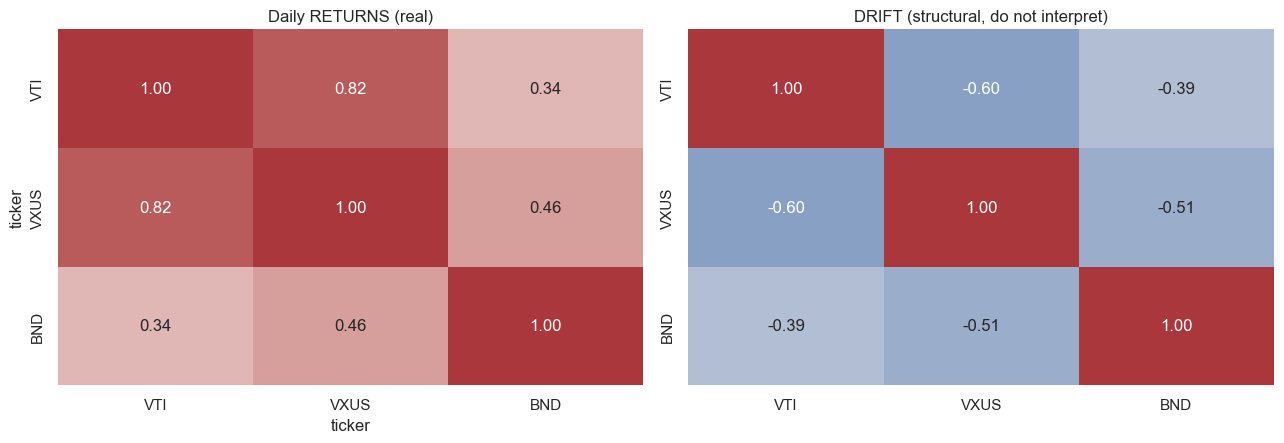

drift columns sum to (should be ~0 on every row): 2.353672812205332e-14


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

sns.heatmap(rets.corr(), annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1,
            ax=axes[0], cbar=False)
axes[0].set_title('Daily RETURNS (real)')

sns.heatmap(drift_df.corr(), annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1,
            ax=axes[1], cbar=False)
axes[1].set_title('DRIFT (structural, do not interpret)')

fig.tight_layout()
plt.show()

print('drift columns sum to (should be ~0 on every row):',
      float(drift_df.sum(axis=1).abs().max()))

**What?** The returns matrix shows 0.82 between the equity funds and 0.34 to 0.46
against BND. The drift matrix shows every pair negative. The three drift columns sum to
zero on every row, to within floating point.

**So what?** Only the left panel is data. The right panel is arithmetic: weights sum to
one, so their deviations from a fixed target sum to zero, so the columns are forced to
move against each other whatever the market does. Reading it as "the funds diversify each
other" would be a real mistake, and it is the kind of mistake a heatmap makes easy,
because both panels look equally like results.

This is the reading's point about correlation being a hint rather than a claim, in its
sharpest form: here the correlation is not even a hint, it is a restatement of the
definition of a weight.

**Now what?** Only the returns matrix informs feature selection. Which pairs actually
matter: VTI and VXUS, because 0.82 is high enough to force a choice between them.
Everything involving BND is low enough to keep.

## 10. The reusable helper: `src/eda.py`

`eda_summary` is the lecture's function, moved into a module so the project imports it
rather than pasting it. `flag_columns` is the stretch goal: it turns the profile into a
short list of columns that need a decision, instead of a wide table someone has to read.

In [19]:
from src.eda import eda_summary, flag_columns

summary = eda_summary(panel)

print('shape   :', summary['shape'])
print('missing :', {k: v for k, v in summary['missing'].items() if v})
print('missing %:', {k: v for k, v in summary['missing_pct'].items() if v})
print()
display(summary['numeric_profile'])

shape   : (753, 10)
missing : {'ret': 3, 'direction': 3}
missing %: {'ret': 0.4, 'direction': 0.4}



,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
close,753.0,166.377,127.350,70.870,74.200,79.560,330.710,384.300,0.728,-1.433
ret,750.0,0.001,0.008,-0.037,-0.003,0.001,0.004,0.041,-0.080,4.108
weight,753.0,0.333,0.208,0.082,0.096,0.309,0.597,0.609,0.180,-1.498
drift_pp,753.0,0.000,0.863,-1.769,-0.583,0.010,0.515,2.233,0.058,-0.446


In [20]:
flagged = flag_columns(panel)
if flagged.empty:
    print('nothing flagged at the default thresholds')
else:
    print(flagged.to_string(index=False))

column             issue  value  threshold
  flag dominant category  100.0       95.0


**What?** The only missingness is 3 values in `ret` and 3 in `direction`, which is the
first trading day: there is no return on the first observation because there is no prior
close. `flag_columns` returns exactly one row: `flag` is a dominant category at 100%.

**So what?** Both results are useful precisely because they are boring. The `ret` NaNs
are structural, not a data fault, so the correct handling is to drop the first row when
returns are needed and never to impute it. The `flag` result is the section 5 finding
arriving automatically, which is the point of writing the check as a function: the next
stage does not have to remember to look.

**Now what?** `src/eda.py` is imported unchanged by the project pipeline in Stage 08's
project half.

## 11. Stretch: the same data at two granularities

The daily series is what the monitor runs on. Dana, the client-service associate who
receives the report, does not open it daily. So: what would a month-end report have
missed?

,daily_worst_pp,month_end_worst_pp,missed_pp,observations_daily,observations_month_end
VTI,1.553,1.553,0.000,251,13
VXUS,2.233,2.233,0.000,251,13
BND,1.769,1.705,0.064,251,13


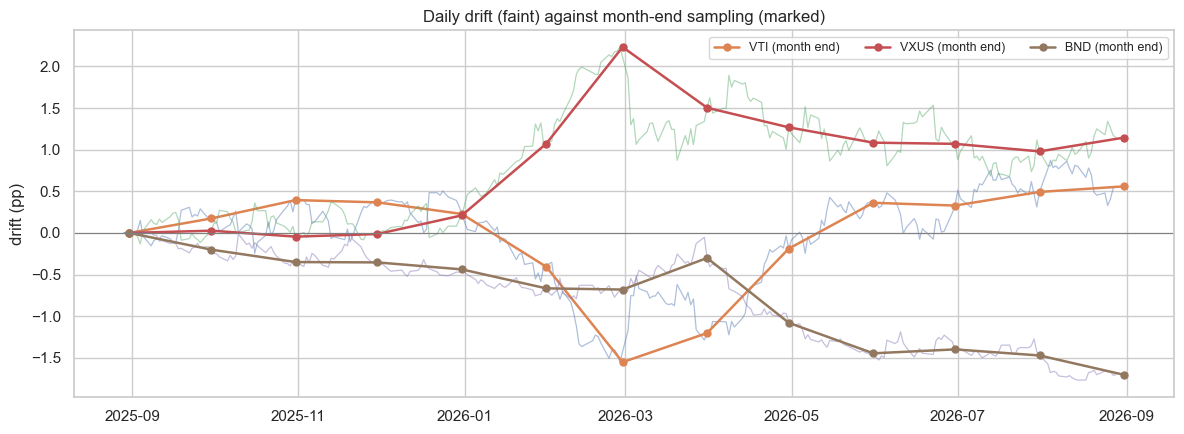

In [21]:
month_end = drift_df.resample('ME').last()

comparison = pd.DataFrame({
    'daily_worst_pp': drift_df.abs().max(),
    'month_end_worst_pp': month_end.abs().max(),
})
comparison['missed_pp'] = (comparison['daily_worst_pp']
                           - comparison['month_end_worst_pp']).round(3)
comparison['observations_daily'] = len(drift_df)
comparison['observations_month_end'] = len(month_end)
display(comparison.round(3))

fig, ax = plt.subplots(figsize=(12, 4.5))
for t in TICKERS:
    ax.plot(drift_df.index, drift_df[t], linewidth=0.9, alpha=0.45)
    ax.plot(month_end.index, month_end[t], marker='o', markersize=5,
            linewidth=1.8, label=f'{t} (month end)')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_title('Daily drift (faint) against month-end sampling (marked)')
ax.set_ylabel('drift (pp)')
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
plt.show()

**What?** Month-end sampling reproduces the worst drift exactly for VTI (1.553pp) and
VXUS (2.233pp), and understates BND by 0.064pp (1.705 against 1.769). Thirteen
observations recover what 251 showed.

**So what?** That is a direct consequence of the section 8 finding rather than a separate
one. When the signal is a slow trend, sampling it 19 times less often loses almost
nothing, because there is no spike to fall between the samples. If the drift were
spiky, the same test would have shown a large gap and the answer would be the opposite.

**Now what?** This is worth putting to the principal. If a monthly report is
operationally cheaper and Dana would actually read it, one year of evidence says it would
have missed 0.064pp on one fund. The honest caveat is that the evidence covers a calm,
trending year, and the test should be re-run if a volatile one arrives.

In [22]:
# Save the tables this notebook produced, so later stages can cite them without re-running.
return_profile.to_csv(PROC / 'eda_return_profile.csv')
drift_profile.to_csv(PROC / 'eda_drift_profile.csv')
trend.to_csv(PROC / 'eda_drift_trend.csv')
flagged.to_csv(PROC / 'eda_flagged_columns.csv', index=False)

for p in sorted(PROC.glob('eda_*.csv')):
    print(f'{p.name:<32} {p.stat().st_size:>6} bytes')

eda_drift_profile.csv               176 bytes
eda_drift_trend.csv                 187 bytes
eda_flagged_columns.csv              63 bytes
eda_return_profile.csv              221 bytes


## 12. Insights, assumptions, and what happens next

### Top 3 insights

**1. The drift is a trend, not noise, and that reframes the whole monitor.**
BND's drift correlates with time at -0.93 and falls at 1.69pp per year; VXUS rises at
1.35pp per year. Underneath is a persistent return spread: +19.2% and +22.6% for the two
equity funds against -2.0% for the bond fund. So the 3pp and 5pp thresholds are not
mis-set and the alarm is not broken. On the observed rates, BND reaches amber in about
1.8 years and red in about 3.0. The monitor has been shown one year of a three-year
phenomenon. That is a reportable finding rather than a silent null.

**2. The date axis is business-daily and clean, and treating it as calendar-daily would
quietly corrupt Stage 09.**
251 rows, sorted, no duplicates, and the only ten absent business days are named US
market holidays. But 114 calendar days are missing, so a 7-row rolling window spans 9
calendar days on average and 11 over a holiday weekend, and reindexing to `freq='D'`
would insert 114 empty rows that dilute every rolling statistic. Nothing warns you when
this goes wrong, which is why it is checked here rather than debugged there.

**3. Two of the three funds are close to one fund, and the third is the only real
diversifier.**
VTI and VXUS daily returns correlate at 0.82, so one explains 67% of the other's
variance. BND correlates at 0.34 with VTI. Separately, the drift correlation matrix is
negative on every pair for a purely structural reason (weights sum to one, so drifts sum
to zero) and carries no information at all.

### Assumptions and risks

| Assumption | Risk if wrong |
|---|---|
| One year of daily closes represents the behaviour worth monitoring | The window is a calm, trending market. A 2008 or a 2020 would show spikes that this analysis says do not exist, and the monthly-sampling conclusion would invert. |
| The linear extrapolation of drift rates is indicative, not a forecast | It assumes the equity-bond spread persists. It will not persist indefinitely, and mean reversion would push the amber dates out. The rate is a way to size the problem, not a prediction to act on. |
| Prices are correct as delivered by yfinance | Stage 07 examined 24 IQR-flagged fund-days and found them all to be genuine market moves, including five dates where two funds moved together. No prices were removed. That conclusion is inherited here. |
| Dates with an incomplete set of closes were correctly dropped upstream | Stage 06 deletes rather than repairs those days. The result is the zero missingness reported here. The deletions are invisible in this file. |
| Percentage points are the right unit for the threshold | BND's worst drift is 17.7% of its target; VTI's is 2.6% of its. The single pp rule is least sensitive where a given move matters most. Flagged in Stage 07's `docs/outliers.md`, still open, and a decision for the principal. |

### Next steps before modelling

**Cleaning:** nothing further. The frame is complete, correctly typed, sorted, and
free of duplicates. The three `ret` NaNs are the first trading day and get dropped, never
imputed.

**Features for Stage 09**, in priority order:

1. First difference of drift, and a rolling 21-day and 63-day slope. The level is
   dominated by a trend; the rate is where the information is.
2. Equity-minus-bond return spread, which is the mechanism actually producing the drift.
3. 21-day realized volatility per fund. The rolling vol plot shows clear clustering, so
   this is a real feature rather than a decorative one.
4. Calendar features (month, day of week) are **not** worth building. There is no
   seasonality in this series and the weekday means of daily drift change are all within
   0.03pp of zero.
5. Drop one of VTI / VXUS, or replace the pair with a spread. Do not feed both to a
   linear model at 0.82.

All of it is built on the existing business-day index, labelled in trading days, with no
reindexing to a calendar-day frequency.

**For Stage 10b:** split chronologically and report the drift range of each side next to
the score. A random split would leak, and a chronological one puts the test set out of
distribution. Both facts belong in the write-up.